# 04 — Learned embeddings

**Dataset:** `aim_2023`

**Question:** Does masked reconstruction learn useful recurrence neighborhoods?

## Method

Train compact temporal encoder on training recordings only, then inspect held-out reconstruction and neighbors.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "lap_estimation").exists():
    ROOT = ROOT.parent
if not (ROOT / "lap_estimation").exists():
    raise FileNotFoundError("Repository root not found")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lap_estimation.plotting_learned import render_embedding_diagnostics
from lap_estimation.artifacts import load_experiment_metrics
from lap_estimation.config import RANDOM_SEED
from lap_estimation.data import prepare_recording_manifest
from lap_estimation.datasets import resolve_dataset
from lap_estimation.runners import run_experiment

DATASET_KEY = "aim_2023"
dataset = resolve_dataset(DATASET_KEY, ROOT)
ARTIFACT_ROOT = dataset.artifact_root
np.random.seed(RANDOM_SEED)
sns.set_theme(style="ticks", palette="colorblind", context="notebook")
manifest = prepare_recording_manifest(dataset)
manifest[["recording_id", "duration_s", "motion_status", "control_candidate", "clock_provenance", "split"]]

,recording_id,duration_s,motion_status,control_candidate,clock_provenance,split
0,18385fe48224fbfa0cd6d17705d9305f857d70ef07b47b...,228.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
1,27937681c8199780c6cbce603f217d5a4457c351e84fa3...,217.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
2,4975a35d789765b9299480af66d6a5af5166fef074cef8...,210.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
3,5790cd1534b1de5ac4693367fe5d8ca6951cd36a7abcd3...,25.95,low_dynamics_candidate,True,inferred_uniform_from_metadata,train
4,5c12d7b5eff374be805bae6c5e2906f6c02b6bc3ad6ba7...,89.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
5,5c8af6b8a89a449144e0ddf74414040b433d630e1fd3d3...,33.95,low_dynamics_candidate,True,inferred_uniform_from_metadata,train
6,6732a35a8f6343dcf041f1a3ad40d6760331513a2556c4...,21.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
7,7208a43e77536a72e401c00f01a793130fb6688d28fb80...,9.95,low_dynamics_candidate,True,inferred_uniform_from_metadata,train
8,73093667f33a7f710fc20059989a002071359119e1e9c0...,10.95,low_dynamics_candidate,True,inferred_uniform_from_metadata,train
9,8f799d59c9b5348ece1e5671692ea783d6d5e450ccebe3...,107.95,dynamic_candidate,False,inferred_uniform_from_metadata,train


In [2]:
EXPERIMENT_OPTIONS = {'epochs': 20}
EXPERIMENT_OPTIONS

{'epochs': 20}

,task,split,metric,value,sample_count,reference_source
0,masked_signal_prediction,train,mean_reconstruction_mse,47.257380,662,none
1,masked_signal_prediction,validation,mean_reconstruction_mse,96.149936,61,none
2,masked_signal_prediction,test,mean_reconstruction_mse,21.756220,213,none
3,masked_signal_prediction,all,mean_reconstruction_mse,44.640605,936,none
4,embedding_retrieval,train,mean_neighbor_cosine_similarity,0.998344,662,none
5,embedding_retrieval,validation,mean_neighbor_cosine_similarity,0.989338,61,none
6,embedding_retrieval,test,mean_neighbor_cosine_similarity,0.999793,213,none
7,embedding_retrieval,all,mean_neighbor_cosine_similarity,0.998087,936,none


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
recording_id,936,18,9116cbf4be063f5be851f65778ddfb91d60bdd5aa52e72...,224,NaN,NaN,NaN,NaN,NaN,NaN,NaN
segment_id,936,936,window_0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_s,936.0,NaN,NaN,NaN,118.839744,101.772946,0.0,40.0,94.0,168.0,446.0
end_s,936.0,NaN,NaN,NaN,128.839744,101.772946,10.0,50.0,104.0,178.0,456.0
prediction_kind,936,1,masked_prediction_embedding_neighbor,936,NaN,NaN,NaN,NaN,NaN,NaN,NaN
score,936.0,NaN,NaN,NaN,0.998087,0.013732,0.68475,0.999842,0.999972,0.999993,1.0
label_status,936,1,provisional_unverified,936,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbor_recording_id,936,17,9116cbf4be063f5be851f65778ddfb91d60bdd5aa52e72...,220,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbor_start_s,936.0,NaN,NaN,NaN,116.807692,98.271682,0.0,43.5,90.0,166.5,432.0
temporal_separation_s,936.0,NaN,NaN,NaN,86.339744,85.279082,0.0,28.0,58.0,114.0,442.0


,count,mean,median,std,min,max
recording_id,,,,,,
dc8bf44eb4cc0becf1c5ebe252a515c98193744c2031498501de80e036899758,84,0.999979,0.999993,0.000028,0.999884,0.999999
18385fe48224fbfa0cd6d17705d9305f857d70ef07b47b55502d04ff71359269,110,0.998918,0.999989,0.002767,0.985181,0.999999
973ef84ffaa4e83d002ed655331eb305b340c0f3f25b57795f97a151bcc3490b,2,0.999986,0.999986,0.000010,0.999979,0.999993
bace0e92b25324e8afbd0e5f6698b01a921780a2385e02419965fa97e3e796c4,117,0.999760,0.999984,0.001019,0.990774,1.000000
8f799d59c9b5348ece1e5671692ea783d6d5e450ccebe31b6db9ad4f9510f8c5,50,0.998522,0.999984,0.006974,0.952502,0.999999
c3c503093a73b359d513d025d9185c7ada423099650828cbd4fdba12d1d7aafc,6,0.999924,0.999982,0.000099,0.999757,0.999995
5c8af6b8a89a449144e0ddf74414040b433d630e1fd3d3ddc138ec3c4284d97b,13,0.999950,0.999976,0.000048,0.999840,0.999994
9116cbf4be063f5be851f65778ddfb91d60bdd5aa52e7211426769a6b2ce6f86,224,0.998334,0.999969,0.014957,0.821038,1.000000
b185f43818b8ff3aba325752922bbbf37fd094f1e282887487651e0a5c8f6c7a,58,0.988788,0.999966,0.043322,0.684750,0.999999


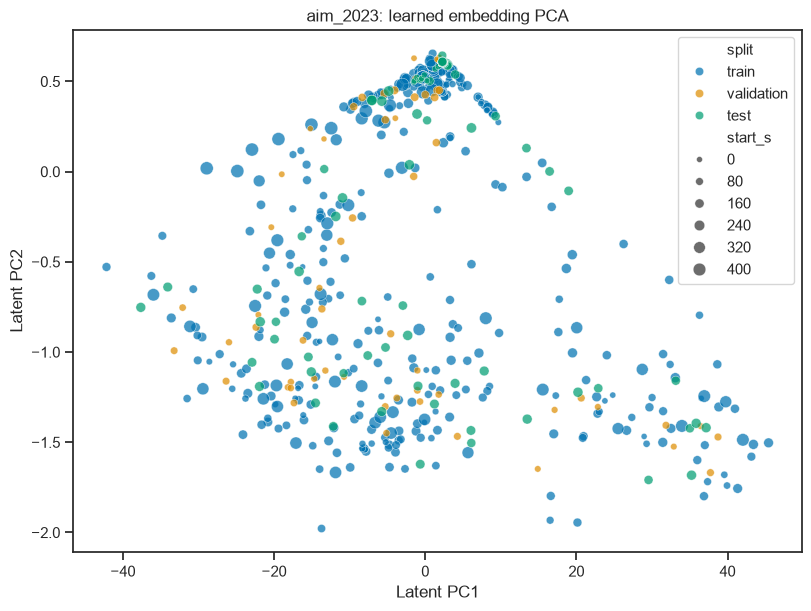

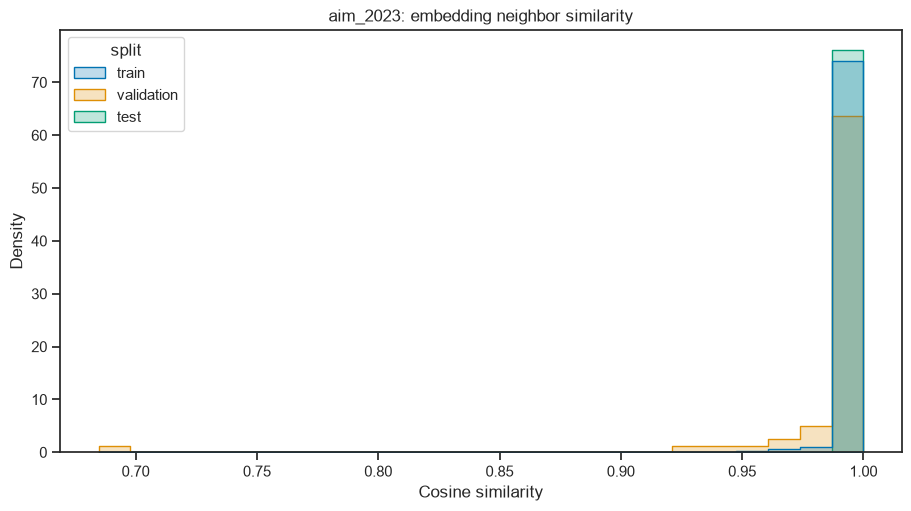

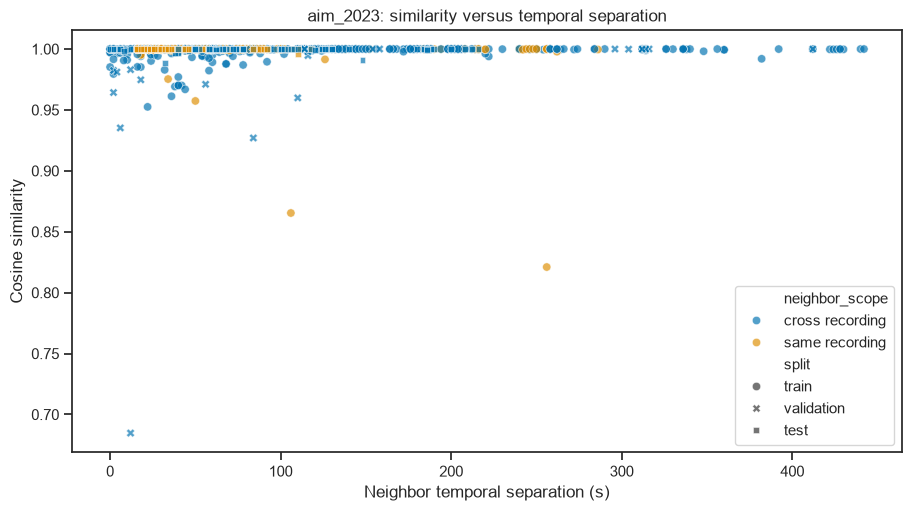

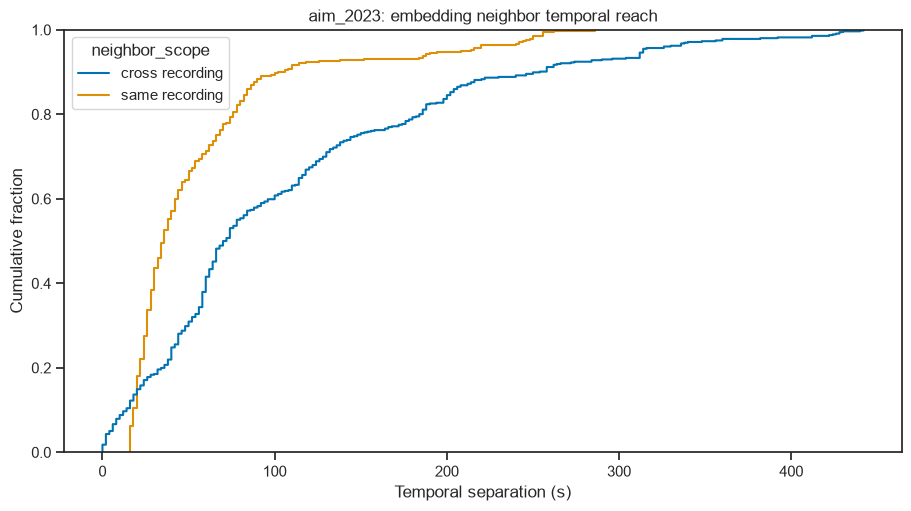

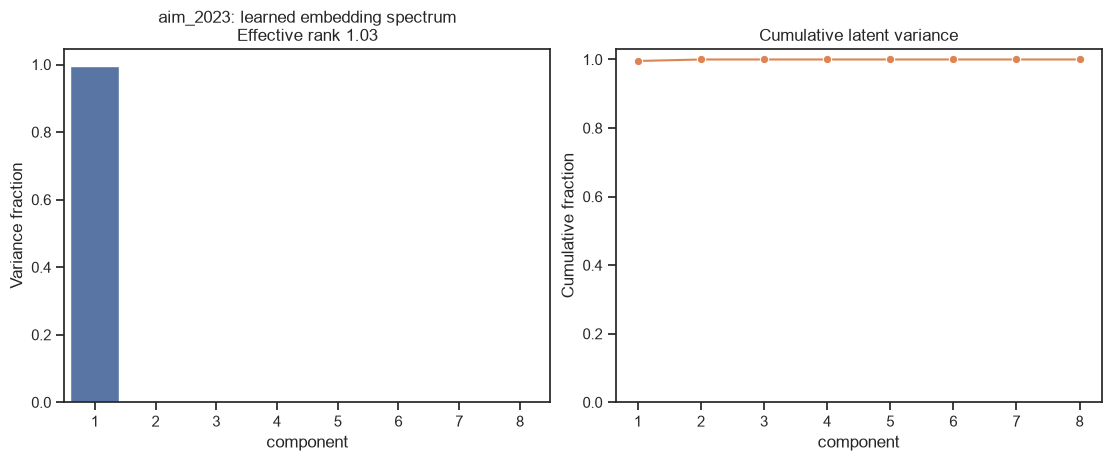

In [3]:
METHOD = "04_learned_embeddings"
result = run_experiment(METHOD, ROOT, dataset_key=DATASET_KEY, **EXPERIMENT_OPTIONS)
run_manifest = json.loads((result.output_dir / "manifest.json").read_text(encoding="utf-8"))
display(result.metrics)
display(result.predictions.describe(include="all").T)
display(result.predictions.groupby("recording_id")["score"].agg(["count", "mean", "median", "std", "min", "max"]).sort_values("median", ascending=False))
diagnostic_figures = render_embedding_diagnostics(result.predictions, run_manifest, result.output_dir)
for figure in diagnostic_figures.values():
    display(figure)
    plt.close(figure)

In [4]:
pd.Series(
    {
        "status": run_manifest["status"],
        "runtime_s": run_manifest["runtime_s"],
        "clock_provenance": run_manifest["data_provenance"]["clock_provenance"],
        "sample_rate_hz": run_manifest["data_provenance"]["native_sample_rate_hz"],
        "channels": run_manifest["data_provenance"]["selected_channels"],
        "label_provenance": run_manifest["label_provenance"],
    },
    name="value",
).to_frame()

,value
status,complete
runtime_s,5.602
clock_provenance,inferred_uniform_from_metadata
sample_rate_hz,20.0
channels,"[InlineAcc, LateralAcc, RollRate, PitchRate, Y..."
label_provenance,self_supervised_unverified


## Reading

Near-unity similarity may reflect overlapping windows or collapse. Reconstruction is not lap accuracy.

No lap precision, recall, count error, or duration error can be reported without independently reviewed boundaries.